# Nuclei Segmentation — Μέρος Β.2: U-Net
**Instance segmentation των πυρήνων με ένα U-Net (PyTorch).**

Σε αυτό το ερώτημα υλοποιούμε και εκπαιδεύουμε ένα μοντέλο **U-Net** για το πρόβλημα
εντοπισμού & κατάτμησης πυρήνων του Data Science Bowl 2018.

**Θεωρητικό υπόβαθρο (Διάλεξη 4 — Convolutional Neural Networks):** Η κατάτμηση εικόνας
αντιμετωπίζεται ως *«multivariate binary classification problem (many outputs, two
discrete classes)»* με ένα **convolutional encoder–decoder network**. Δηλαδή το δίκτυο
προβλέπει για **κάθε pixel** αν ανήκει σε πυρήνα ή στο background. Το **U-Net** (Διάλεξη 4)
είναι ακριβώς ένα τέτοιο encoder–decoder με **skip connections**.

Επειδή το ζητούμενο είναι *instance* segmentation (να ξεχωρίζει ο κάθε πυρήνας), μετά το
U-Net προσθέτουμε ένα **κλασικό βήμα post-processing (watershed)** που σπάει το binary mask
σε ξεχωριστούς πυρήνες.

## 0.1 Προετοιμασία Δεδομένων: Αποσυμπίεση `stage1_train.zip` και `stage1_test.zip`

Το notebook αναμένει ότι οι φάκελοι `train` και `test` βρίσκονται στη διαδρομή `../data/raw/`. Επειδή τα δεδομένα σας είναι σε αρχεία `.zip`, πρέπει πρώτα να τα αποσυμπιέσετε.

Ακολουθούν τα βήματα:
1. Δημιουργήστε τον κατάλογο `data/raw`.
2. **Ανεβάστε τα αρχεία `stage1_train.zip` και `stage1_test.zip` στο περιβάλλον του Colab.** (Μπορείτε να τα σύρετε και να τα αποθέσετε στην αριστερή πλευρική γραμμή, στην ενότητα 'Files', ή να χρησιμοποιήσετε την εντολή `files.upload()`).
3. Αποσυμπιέστε τα αρχεία `stage1_train.zip` και `stage1_test.zip` στον κατάλογο `../data/raw/`.
4. Ενημερώστε τις μεταβλητές `TRAIN_DIR` και `TEST_DIR` ώστε να δείχνουν στους σωστούς αποσυμπιεσμένους φακέλους.

In [20]:
# Δημιουργία των απαραίτητων καταλόγων
import os
from pathlib import Path

# Χρησιμοποιούμε απόλυτη διαδρομή για καλύτερη συμβατότητα στο Colab
DATA_RAW_DIR = Path('/content/data/raw')
DATA_RAW_DIR.mkdir(parents=True, exist_ok=True)
print(f'Δημιουργήθηκε ο κατάλογος: {DATA_RAW_DIR}')

Δημιουργήθηκε ο κατάλογος: /content/data/raw


In [21]:
# Καθαρισμός του DATA_RAW_DIR από προηγούμενες λανθασμένες αποσυμπιέσεις
import shutil
if DATA_RAW_DIR.exists():
    for item in os.listdir(DATA_RAW_DIR):
        item_path = DATA_RAW_DIR / item
        if item_path.is_dir():
            shutil.rmtree(item_path)
        else:
            os.remove(item_path)
    print(f'Καθαρίστηκαν τα περιεχόμενα του: {DATA_RAW_DIR}')

Καθαρίστηκαν τα περιεχόμενα του: /content/data/raw


In [22]:
# Αποσυμπίεση του stage1_train.zip στον υποφάκελο stage1_train
!unzip -q /content/stage1_train.zip -d {DATA_RAW_DIR}/stage1_train/
print('Το αρχείο stage1_train.zip αποσυμπιέστηκε στον φάκελο stage1_train.')

Το αρχείο stage1_train.zip αποσυμπιέστηκε στον φάκελο stage1_train.


In [23]:
# Αποσυμπίεση του stage1_test.zip στον υποφάκελο stage1_test
!unzip -q /content/stage1_test.zip -d {DATA_RAW_DIR}/stage1_test/
print('Το αρχείο stage1_test.zip αποσυμπιέστηκε στον φάκελο stage1_test.')

Το αρχείο stage1_test.zip αποσυμπιέστηκε στον φάκελο stage1_test.


In [24]:
# Επιβεβαίωση περιεχομένων του DATA_RAW_DIR μετά την αποσυμπίεση
print(f'Περιεχόμενα του {DATA_RAW_DIR}:')
for item in os.listdir(DATA_RAW_DIR):
    print(f'- {item}')

# Επίσης, ελέγχουμε αν οι συγκεκριμένοι φάκελοι υπάρχουν
print(f'Το {DATA_RAW_DIR}/stage1_train υπάρχει: {Path(DATA_RAW_DIR / 'stage1_train').exists()}')
print(f'Το {DATA_RAW_DIR}/stage1_test υπάρχει: {Path(DATA_RAW_DIR / 'stage1_test').exists()}')

Περιεχόμενα του /content/data/raw:
- stage1_test
- stage1_train
Το /content/data/raw/stage1_train υπάρχει: True
Το /content/data/raw/stage1_test υπάρχει: True


In [25]:
# Επιβεβαίωση περιεχομένων του DATA_RAW_DIR μετά την αποσυμπίεση
print(f'Περιεχόμενα του {DATA_RAW_DIR}:')
for item in os.listdir(DATA_RAW_DIR):
    print(f'- {item}')

# Επίσης, ελέγχουμε αν οι συγκεκριμένοι φάκελοι υπάρχουν
print(f'Το {DATA_RAW_DIR}/stage1_train υπάρχει: {Path(DATA_RAW_DIR / 'stage1_train').exists()}')
print(f'Το {DATA_RAW_DIR}/stage1_test υπάρχει: {Path(DATA_RAW_DIR / 'stage1_test').exists()}')

Περιεχόμενα του /content/data/raw:
- stage1_test
- stage1_train
Το /content/data/raw/stage1_train υπάρχει: True
Το /content/data/raw/stage1_test υπάρχει: True


In [26]:
# Αυτό το κελί πλέον είναι περιττό καθώς οι μεταβλητές TRAIN_DIR και TEST_DIR ορίζονται αλλού.

## 0. Imports & Config

In [27]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# watershed για το instance segmentation στο τελος (κλασικο computer vision)
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

import warnings
warnings.filterwarnings('ignore')


# Ενημερώνουμε τις TRAIN_DIR και TEST_DIR να δείχνουν στους σωστούς φακέλους
TRAIN_DIR = DATA_RAW_DIR / 'stage1_train'
TEST_DIR  = DATA_RAW_DIR / 'stage1_test'

# Hyperparameters (μπορεις να πειραματιστεις)
IMG_SIZE   = 256      # resize ολων των εικονων (το dataset εχει 9 διαφορετικα μεγεθη)
BATCH_SIZE = 8
EPOCHS     = 25
LR         = 1e-3
VAL_SPLIT  = 0.1      # 10% για validation
SEED       = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# Για επαναληψιμοτητα
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'TRAIN_DIR: {TRAIN_DIR}')
print(f'TEST_DIR: {TEST_DIR}')
print('Train dir exists:', TRAIN_DIR.exists())

Device: cuda
TRAIN_DIR: /content/data/raw/stage1_train
TEST_DIR: /content/data/raw/stage1_test
Train dir exists: True


## 1. Dataset & DataLoaders

Όπως στο Εργαστήριο 2, φτιάχνουμε μια κλάση `Dataset` και κάνουμε το split με
**`random_split`**. Η `NucleiDataset`:
1. Διαβάζει την εικόνα, την κάνει **RGB** (έτσι RGBA & grayscale γίνονται ομοιόμορφα 3 κανάλια)
   και resize σε `IMG_SIZE x IMG_SIZE`.
2. Ενώνει **όλα τα masks** του δείγματος σε ένα **binary mask** (1 = πυρήνας, 0 = background).
3. Κάνει απλό **data augmentation** (τυχαία αναστροφή — spatial transform, Διάλεξη 4 σελ. 59),
   μόνο στο train.


In [28]:
def combine_masks(mask_dir, size):
    """Ενωνει ολα τα .png masks ενος δειγματος σε ενα binary mask (0/1)."""
    combined = np.zeros((size, size), dtype=np.float32)
    for mask_file in sorted(mask_dir.glob('*.png')):
        m = Image.open(mask_file).convert('L').resize((size, size), Image.NEAREST)
        m = np.array(m)
        combined[m > 0] = 1.0
    return combined


class NucleiDataset(Dataset):
    def __init__(self, data_dir, image_ids, size=256, augment=False):
        self.data_dir = data_dir
        self.image_ids = image_ids
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]

        # --- εικονα ---
        img_path = self.data_dir / img_id / 'images' / f'{img_id}.png'
        img = Image.open(img_path).convert('RGB').resize((self.size, self.size))
        img = np.array(img, dtype=np.float32) / 255.0    # κανονικοποιηση στο [0,1]

        # --- mask (ολα τα nuclei μαζι σε binary) ---
        mask = combine_masks(self.data_dir / img_id / 'masks', self.size)

        # --- augmentation: τυχαια αναστροφη (μονο στο train) ---
        if self.augment:
            if random.random() < 0.5:
                img = np.fliplr(img).copy();  mask = np.fliplr(mask).copy()
            if random.random() < 0.5:
                img = np.flipud(img).copy();  mask = np.flipud(mask).copy()

        # σε tensors: εικονα -> (C,H,W), mask -> (1,H,W)
        img = torch.from_numpy(img).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()
        return img, mask

In [29]:
# Λιστα με ολα τα image ids
all_ids = sorted(os.listdir(TRAIN_DIR))

# Split train/val με random_split (οπως στο Εργαστηριο 2)
n_val = int(len(all_ids) * VAL_SPLIT)
n_train = len(all_ids) - n_val
generator = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(range(len(all_ids)), [n_train, n_val], generator=generator)

train_ids = [all_ids[i] for i in train_idx]
val_ids   = [all_ids[i] for i in val_idx]
print(f'Train: {len(train_ids)} | Validation: {len(val_ids)}')

# augmentation ΜΟΝΟ στο train
train_data = NucleiDataset(TRAIN_DIR, train_ids, size=IMG_SIZE, augment=True)
valid_data = NucleiDataset(TRAIN_DIR, val_ids,   size=IMG_SIZE, augment=False)

# num_workers=0 για να μην εχουμε προβληματα σε Windows / Colab
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
valid_dataloader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Train: 603 | Validation: 67


image tensor: torch.Size([3, 256, 256]) | mask tensor: torch.Size([1, 256, 256])


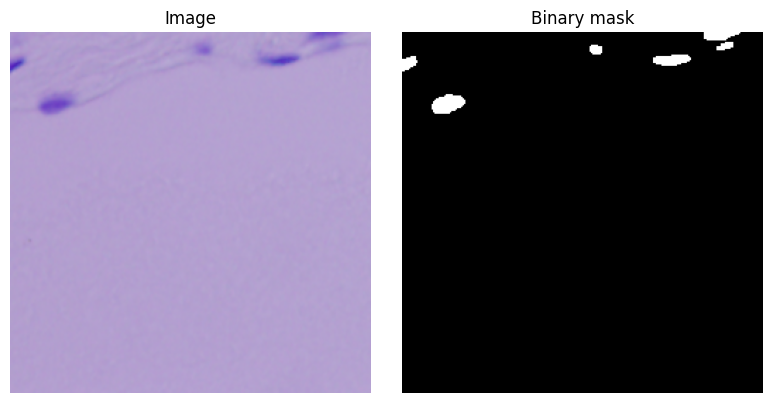

In [30]:
# Ας δουμε ενα δειγμα (εικονα + mask) για να ειμαστε σιγουροι οτι φορτωνονται σωστα
img, mask = train_data[0]
print('image tensor:', img.shape, '| mask tensor:', mask.shape)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img.permute(1, 2, 0).numpy()); ax[0].set_title('Image'); ax[0].axis('off')
ax[1].imshow(mask[0].numpy(), cmap='gray');  ax[1].set_title('Binary mask'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 2. Το μοντέλο U-Net

Υλοποιούμε το U-Net (Διάλεξη 4, σελ. 76) από την αρχή. Χρησιμοποιεί όλα τα δομικά
στοιχεία που είδαμε στη θεωρία:
- **Convolutional layers** (`Conv2d`) + **BatchNorm** + **ReLU** — με τη σειρά Conv → BN → ReLU
  (Διάλεξη 4, σελ. 74: «Order of operations is important + Batch Norm»).
- **Downsampling** με **Max pooling** (Διάλεξη 4, σελ. 48).
- **Upsampling** με **transposed convolutions** (`ConvTranspose2d`, Διάλεξη 4, σελ. 53–54).
- **Skip connections** που ενώνουν τα features του encoder με του decoder (χαρακτηριστικό του U-Net).
- Τελικό **1x1 convolution** (Διάλεξη 4, σελ. 55) για να βγάλουμε 1 κανάλι εξόδου.


In [31]:
class DoubleConv(nn.Module):
    """Δυο φορες (Conv -> BatchNorm -> ReLU), το βασικο μπλοκ του U-Net."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base=32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)        # downsampling

        # Encoder
        self.enc1 = DoubleConv(in_ch,    base)        # 256
        self.enc2 = DoubleConv(base,     base * 2)    # 128
        self.enc3 = DoubleConv(base * 2, base * 4)    # 64
        self.enc4 = DoubleConv(base * 4, base * 8)    # 32

        # Bottleneck
        self.bottleneck = DoubleConv(base * 8, base * 16)   # 16

        # Decoder (transposed conv για upsampling + DoubleConv μετα το concat)
        self.up4  = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3  = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2  = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1  = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)

        self.out_conv = nn.Conv2d(base, out_ch, kernel_size=1)   # 1x1 convolution

    def forward(self, x):
        # encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        # decoder + skip connections
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out_conv(d1)    # logits (χωρις sigmoid, το αναλαμβανει το BCEWithLogitsLoss)


model = UNet(in_ch=3, out_ch=1, base=32).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'U-Net parameters: {n_params:,}')

# Γρηγορος ελεγχος οτι τα σχηματα ειναι σωστα
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
print('output shape:', model(dummy).shape)    # περιμενουμε (2,1,256,256)

U-Net parameters: 7,765,985
output shape: torch.Size([2, 1, 256, 256])


## 3. Loss & Μετρικές

Αφού η κατάτμηση είναι **binary classification ανά pixel** (Διάλεξη 4, σελ. 4), η φυσική
συνάρτηση κόστους είναι η **Binary Cross Entropy**. Χρησιμοποιούμε την
`nn.BCEWithLogitsLoss`,
που εφαρμόζει εσωτερικά sigmoid + BCE και είναι αριθμητικά σταθερή.

Για να **παρακολουθούμε** την ποιότητα της κατάτμησης (πέρα από το loss) κρατάμε δύο
στάνταρ μετρικές segmentation: **Dice coefficient** και **IoU** (αυτές χρησιμοποιούνται
και στο ερώτημα Β.4).


In [32]:
# Loss: binary classification ανα pixel -> BCE
loss_fn = nn.BCEWithLogitsLoss()


@torch.no_grad()
def dice_coef(logits, targets, thr=0.5, eps=1e-6):
    preds = (torch.sigmoid(logits) > thr).float().view(logits.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter = (preds * targets).sum(1)
    return ((2 * inter + eps) / (preds.sum(1) + targets.sum(1) + eps)).mean().item()


@torch.no_grad()
def iou_coef(logits, targets, thr=0.5, eps=1e-6):
    preds = (torch.sigmoid(logits) > thr).float().view(logits.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter = (preds * targets).sum(1)
    union = preds.sum(1) + targets.sum(1) - inter
    return ((inter + eps) / (union + eps)).mean().item()

## 4. Εκπαίδευση

Ακολουθούμε τη **δομή του Εργαστηρίου 2**: μια συνάρτηση `train()` για το πέρασμα
εκπαίδευσης και μια `evaluate()` για το validation, και τις καλούμε σε έναν βρόχο
`for t in range(EPOCHS)`. Optimizer: **Adam** (όπως στα Εργαστήρια 1, 2 & 4).


In [33]:
def train(dataloader, model, loss_fn, optimizer):
    """Ενα περασμα εκπαιδευσης πανω σε ολο το dataloader (οπως Εργαστηριο 2)."""
    model.train()
    total_loss = 0.0
    for X, y in tqdm(dataloader, desc='train', leave=False):
        X, y = X.to(DEVICE), y.to(DEVICE)

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
    return total_loss / len(dataloader.dataset)


def evaluate(dataloader, model, loss_fn):
    """Αξιολογηση στο validation: loss + Dice + IoU."""
    model.eval()
    total_loss = total_dice = total_iou = 0.0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            pred = model(X)
            total_loss += loss_fn(pred, y).item() * X.size(0)
            total_dice += dice_coef(pred, y)       * X.size(0)
            total_iou  += iou_coef(pred, y)        * X.size(0)
    n = len(dataloader.dataset)
    return total_loss / n, total_dice / n, total_iou / n

In [34]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}
best_dice = 0.0
os.makedirs('../outputs', exist_ok=True)

for t in range(EPOCHS):
    print(f'Epoch {t + 1}/{EPOCHS}\n-------------------------------')
    train_loss = train(train_dataloader, model, loss_fn, optimizer)
    val_loss, val_dice, val_iou = evaluate(valid_dataloader, model, loss_fn)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)
    print(f'train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | '
          f'val_dice {val_dice:.4f} | val_iou {val_iou:.4f}')

    # κραταμε το καλυτερο μοντελο
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), '../outputs/unet_best.pth')
        print(f'  -> saved best model (dice={best_dice:.4f})')

print('\nΤελος εκπαιδευσης. Best val Dice:', round(best_dice, 4))

Epoch 1/25
-------------------------------


train_loss 0.4625 | val_loss 0.4512 | val_dice 0.7140 | val_iou 0.5837
  -> saved best model (dice=0.7140)
Epoch 2/25
-------------------------------


train_loss 0.2291 | val_loss 0.2184 | val_dice 0.8314 | val_iou 0.7324
  -> saved best model (dice=0.8314)
Epoch 3/25
-------------------------------


train_loss 0.1477 | val_loss 0.1245 | val_dice 0.8490 | val_iou 0.7543
  -> saved best model (dice=0.8490)
Epoch 4/25
-------------------------------


train_loss 0.1259 | val_loss 0.1132 | val_dice 0.8673 | val_iou 0.7817
  -> saved best model (dice=0.8673)
Epoch 5/25
-------------------------------


...

train_loss 0.0709 | val_loss 0.0895 | val_dice 0.8881 | val_iou 0.8133
Epoch 22/25
-------------------------------


train_loss 0.0712 | val_loss 0.1057 | val_dice 0.8761 | val_iou 0.7995
Epoch 23/25
-------------------------------


train_loss 0.0737 | val_loss 0.0817 | val_dice 0.8977 | val_iou 0.8290
  -> saved best model (dice=0.8977)
Epoch 24/25
-------------------------------


train_loss 0.0702 | val_loss 0.0801 | val_dice 0.8921 | val_iou 0.8204
Epoch 25/25
-------------------------------


train_loss 0.0713 | val_loss 0.0691 | val_dice 0.8944 | val_iou 0.8241

Τελος εκπαιδευσης. Best val Dice: 0.8977


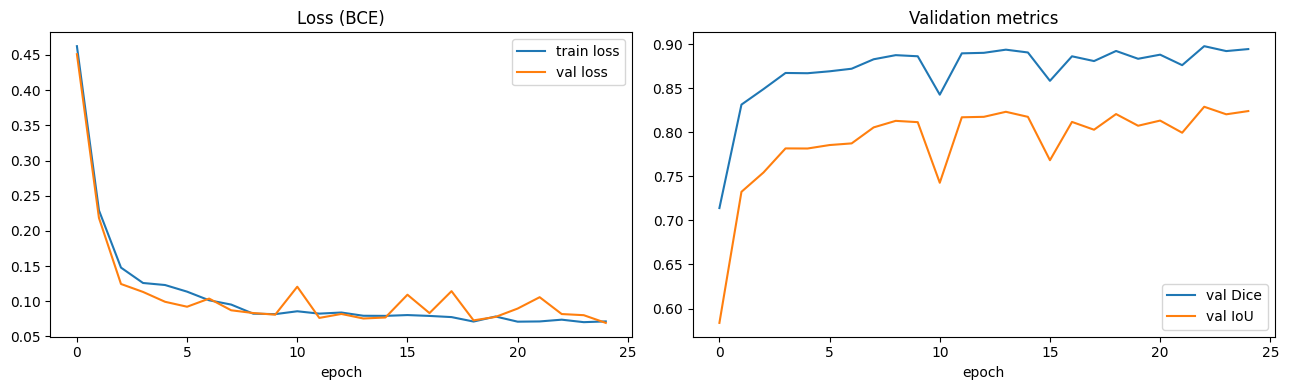

In [35]:
# Καμπυλες εκπαιδευσης
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history['train_loss'], label='train loss')
ax[0].plot(history['val_loss'],   label='val loss')
ax[0].set_title('Loss (BCE)'); ax[0].set_xlabel('epoch'); ax[0].legend()

ax[1].plot(history['val_dice'], label='val Dice')
ax[1].plot(history['val_iou'],  label='val IoU')
ax[1].set_title('Validation metrics'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout()
plt.savefig('../outputs/unet_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Πρόβλεψη + Instance Segmentation (watershed)

Το U-Net δίνει **semantic** segmentation (binary mask: πυρήνας / background). Για να βγάλουμε ξεχωριστά **instances** (απαίτηση
της εργασίας) προσθέτουμε ένα κλασικό βήμα **watershed**:
1. **Distance transform** του foreground (απόσταση κάθε pixel από το background).
2. **Τοπικά μέγιστα** → «κέντρα» των πυρήνων (markers).
3. **Watershed**: κάθε pixel ανατίθεται στον κοντινότερο πυρήνα, ώστε να σπάσουν οι
   κολλημένοι πυρήνες σε ξεχωριστά κομμάτια.


In [36]:
@torch.no_grad()
def predict_mask(model, img_tensor, thr=0.5):
    """Δινει binary mask (numpy) απο ενα image tensor (C,H,W)."""
    model.eval()
    out = model(img_tensor.unsqueeze(0).to(DEVICE))
    prob = torch.sigmoid(out)[0, 0].cpu().numpy()
    return (prob > thr).astype(np.uint8)


def split_instances(binary_mask, min_distance=4):
    """Σπαει ενα binary mask σε ξεχωριστα instances με watershed."""
    if binary_mask.sum() == 0:
        return np.zeros_like(binary_mask, dtype=np.int32)
    dist = ndi.distance_transform_edt(binary_mask)
    coords = peak_local_max(dist, min_distance=min_distance, labels=binary_mask)
    markers = np.zeros(dist.shape, dtype=np.int32)
    for i, (r, c) in enumerate(coords, start=1):
        markers[r, c] = i
    markers, _ = ndi.label(markers > 0)
    return watershed(-dist, markers, mask=binary_mask)


def color_instances(labels):
    """Τυχαια χρωματα σε καθε instance για visualization."""
    out = np.zeros((*labels.shape, 3), dtype=np.uint8)
    rng = np.random.RandomState(42)
    for i in range(1, labels.max() + 1):
        out[labels == i] = rng.randint(50, 255, size=3)
    return out

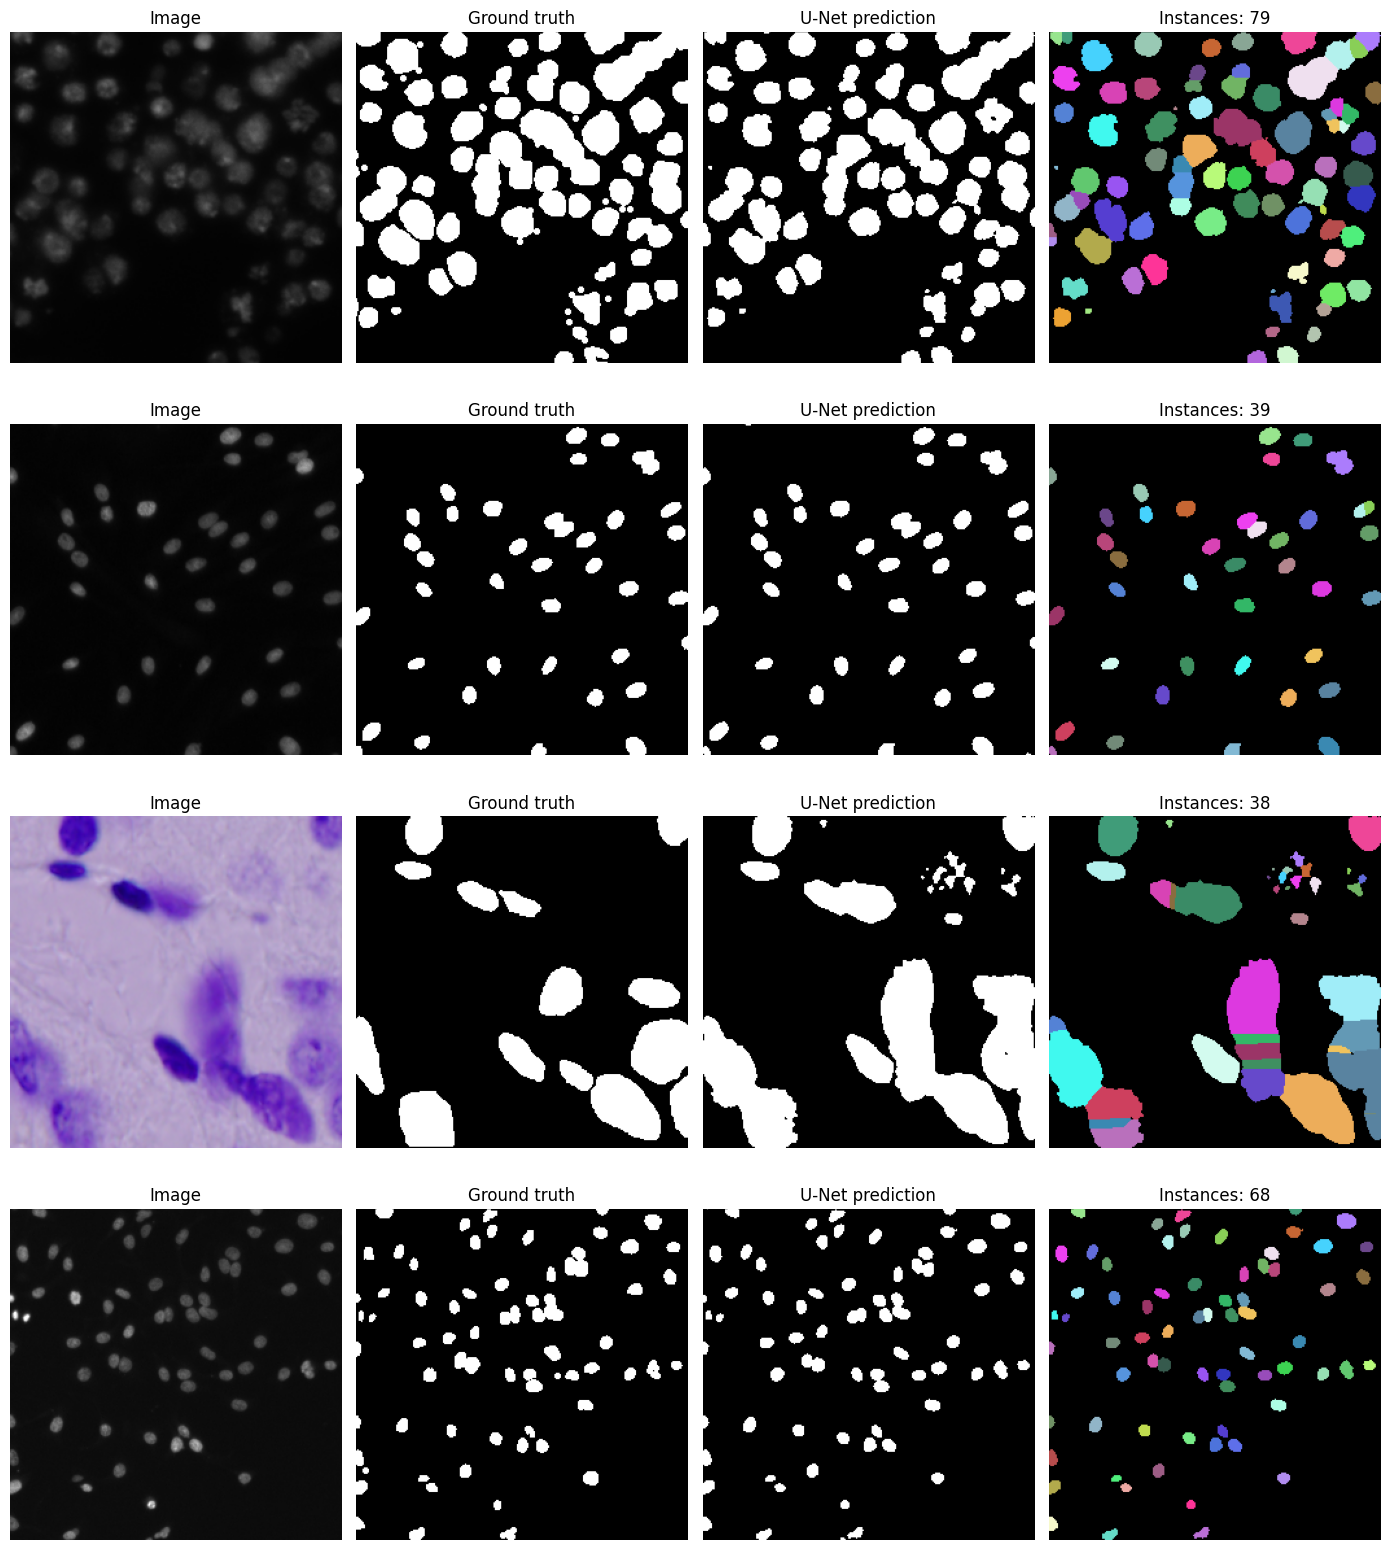

In [37]:
# Φορτωνουμε το καλυτερο μοντελο και δειχνουμε αποτελεσματα σε μερικες val εικονες
model.load_state_dict(torch.load('../outputs/unet_best.pth', map_location=DEVICE))

n_show = 4
fig, axes = plt.subplots(n_show, 4, figsize=(14, 4 * n_show))
for row in range(n_show):
    img, gt_mask = valid_data[row]
    pred_bin = predict_mask(model, img)
    inst = split_instances(pred_bin)

    axes[row, 0].imshow(img.permute(1, 2, 0).numpy())
    axes[row, 0].set_title('Image'); axes[row, 0].axis('off')

    axes[row, 1].imshow(gt_mask[0].numpy(), cmap='gray')
    axes[row, 1].set_title('Ground truth'); axes[row, 1].axis('off')

    axes[row, 2].imshow(pred_bin, cmap='gray')
    axes[row, 2].set_title('U-Net prediction'); axes[row, 2].axis('off')

    axes[row, 3].imshow(color_instances(inst))
    axes[row, 3].set_title(f'Instances: {inst.max()}'); axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig('../outputs/unet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Σύνοψη

- Υλοποιήσαμε το **U-Net** (convolutional encoder–decoder) από την αρχή σε PyTorch.
- Δομικά στοιχεία ακριβώς από τη θεωρία: `Conv2d`+`BatchNorm`+`ReLU`, **MaxPool** (downsampling),
  **ConvTranspose2d** (upsampling), **skip connections**, **1x1 conv** στην έξοδο.
- Loss: **BCEWithLogitsLoss** (κατάτμηση = binary classification ανά pixel), optimizer **Adam**,
  δομή εκπαίδευσης `train()`/`evaluate()`.
- Παρακολούθηση με **Dice** & **IoU**, και μετατροπή σε **instances** με **watershed**.
- Αποθηκεύσαμε το καλύτερο μοντέλο (`../outputs/unet_best.pth`) και τα γραφήματα.

**Πιθανός πειραματισμός:** περισσότερα epochs, augmentation από το Μέρος Α, ή προσθήκη Dice
loss στο BCE για το class imbalance. Η αναλυτική σύγκριση μετρικών με τα άλλα μοντέλα γίνεται
στο ερώτημα **Β.4**.